# NinaPro DB1 — Final Corrected Exploratory Data Analysis

This notebook performs a **complete but focused EDA** of NinaPro DB1. It analyses the full dataset structure and exact counts, then uses balanced samples for heavier plots so the notebook remains readable and memory-efficient.

It covers:

- all 27 subjects, 3 exercises, and 81 MATLAB files;
- 10-channel EMG and 22-channel glove signals;
- synchronization, missing/infinite values, repeated observations, and flat-channel checks;
- correct global movement labels 1–52;
- EMG and glove distributions, rest–movement behaviour, synchronized signal diagrams;
- repetition and between-subject variability;
- annotated EMG, glove, and EMG–glove heatmaps;
- 200 ms window-level features and continuous glove-pose summaries;
- PCA, t-SNE, UMAP, and one interactive plot.

**No classification or regression model is trained in this notebook.**


## 1. Setup and configuration

The default setting downloads the official preprocessed DB1 subject ZIP files into `/kaggle/working/`. If the files are already extracted there, they are reused.

In [1]:
from pathlib import Path
from collections import Counter
import math
import re
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from IPython.display import display
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

RANDOM_STATE = 42
FS = 100                         # NinaPro DB1 sampling frequency
RAW_ROWS_PER_FILE = 2500         # balanced raw-row sample for heavy EDA plots
WINDOW_SAMPLES = 20              # 200 ms at 100 Hz
WINDOW_STEP = 10                 # 100 ms hop = 50% overlap
WINDOW_PURITY = 0.80             # skip windows with strong movement-transition mixing
MAX_WINDOWS_PER_FILE = 350       # balanced window sample for EDA only
EMBEDDING_SAMPLE = 3000

EMG_COLOR = "#1565C0"            # blue
GLOVE_COLOR = "#D32F2F"          # red
LABEL_COLOR = "#2E7D32"          # green

BASE_URL = "https://ninapro.hevs.ch/files/DB1/Preprocessed"
WORK_DIR = Path("/kaggle/working/ninapro_db1") if Path("/kaggle").exists() else Path("./ninapro_db1")
ZIP_DIR = WORK_DIR / "zip_files"
MAT_DIR = WORK_DIR / "mat_files"
ZIP_DIR.mkdir(parents=True, exist_ok=True)
MAT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(RANDOM_STATE)
print("Working directory:", WORK_DIR.resolve())


Working directory: /kaggle/working/ninapro_db1


## 2. Download and extract the official dataset

In [2]:
def natural_key(path):
    name = Path(path).name
    sm = re.search(r"[Ss](\d+)", name)
    em = re.search(r"[Ee](\d+)", name)
    return (
        int(sm.group(1)) if sm else 10**9,
        int(em.group(1)) if em else 10**9,
        name,
    )

for subject in range(1, 28):
    zip_path = ZIP_DIR / f"s{subject}.zip"
    subject_dir = MAT_DIR / f"s{subject}"
    existing = list(subject_dir.rglob("*.mat")) if subject_dir.exists() else []

    if existing:
        print(f"[{subject:02d}/27] extracted files already available")
        continue

    if not (zip_path.exists() and zipfile.is_zipfile(zip_path)):
        zip_path.unlink(missing_ok=True)
        response = requests.get(
            f"{BASE_URL}/s{subject}.zip",
            stream=True,
            timeout=300,
            headers={"User-Agent": "Mozilla/5.0"},
        )
        response.raise_for_status()
        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(1024 * 1024):
                if chunk:
                    file.write(chunk)
        if not zipfile.is_zipfile(zip_path):
            zip_path.unlink(missing_ok=True)
            raise RuntimeError(
                f"Subject {subject} did not download as a valid ZIP. "
                "Use the official NinaPro download if authentication is required."
            )
        print(f"[{subject:02d}/27] downloaded")

    subject_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(subject_dir)

mat_files = sorted(MAT_DIR.rglob("*.mat"), key=natural_key)
print("\nTotal MATLAB files:", len(mat_files))
print("Expected full DB1: 81 files = 27 subjects × 3 exercises")
if len(mat_files) != 81:
    print("WARNING: the file count is not 81. Check the download before final submission.")


[01/27] downloaded
[02/27] downloaded
[03/27] downloaded
[04/27] downloaded
[05/27] downloaded
[06/27] downloaded
[07/27] downloaded
[08/27] downloaded
[09/27] downloaded
[10/27] downloaded
[11/27] downloaded
[12/27] downloaded
[13/27] downloaded
[14/27] downloaded
[15/27] downloaded
[16/27] downloaded
[17/27] downloaded
[18/27] downloaded
[19/27] downloaded
[20/27] downloaded
[21/27] downloaded
[22/27] downloaded
[23/27] downloaded
[24/27] downloaded
[25/27] downloaded
[26/27] downloaded
[27/27] downloaded

Total MATLAB files: 81
Expected full DB1: 81 files = 27 subjects × 3 exercises


## 3. Helper functions

In [3]:
def parse_file_ids(file_path):
    name = Path(file_path).stem
    def get_id(letter):
        match = re.search(fr"[{letter.upper()}{letter.lower()}](\d+)", name)
        return int(match.group(1)) if match else np.nan
    return {
        "subject": get_id("S"),
        "exercise": get_id("E"),
        "acquisition": get_id("A"),
    }


def load_db1(file_path):
    raw = loadmat(file_path, squeeze_me=True, struct_as_record=False)
    def matrix(name):
        return None if name not in raw else np.asarray(raw[name])
    def vector(name):
        value = matrix(name)
        return None if value is None else np.asarray(value).reshape(-1)
    return {
        "emg": matrix("emg"),
        "glove": matrix("glove"),
        "stimulus": vector("stimulus"),
        "restimulus": vector("restimulus"),
        "repetition": vector("repetition"),
        "rerepetition": vector("rerepetition"),
        "subject_value": np.asarray(raw.get("subject", np.nan)).squeeze(),
        "exercise_value": np.asarray(raw.get("exercise", np.nan)).squeeze(),
    }


def movement_name(exercise, local_label):
    return "Rest" if int(local_label) == 0 else f"E{int(exercise)}_M{int(local_label)}"


def global_movement_label(exercise, local_label):
    local_label = int(local_label)
    exercise = int(exercise)
    if local_label == 0:
        return 0
    offsets = {1: 0, 2: 12, 3: 29}
    return offsets[exercise] + local_label


def contiguous_runs(indices):
    indices = np.asarray(indices, dtype=int)
    if len(indices) == 0:
        return []
    split_points = np.where(np.diff(indices) > 1)[0] + 1
    return np.split(indices, split_points)


def describe_columns(dataframe, columns):
    subset = dataframe[columns]
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    outlier_rate = (
        (subset < (q1 - 1.5 * iqr)) |
        (subset > (q3 + 1.5 * iqr))
    ).mean() * 100
    return pd.DataFrame({
        "mean": subset.mean(),
        "median": subset.median(),
        "std": subset.std(),
        "min": subset.min(),
        "q25": q1,
        "q75": q3,
        "max": subset.max(),
        "skewness": subset.skew(),
        "kurtosis": subset.kurtosis(),
        "outlier_%": outlier_rate,
    })


def high_correlation_pairs(dataframe, threshold=0.95):
    corr = dataframe.corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
    return upper[upper.abs() >= threshold].sort_values(key=np.abs, ascending=False)


def annotated_heatmap(matrix, title, xlabels, ylabels, xlabel, ylabel,
                      figsize=(12, 9), font_size=8, cbar_label="Pearson correlation"):
    plt.figure(figsize=figsize)
    sns.heatmap(
        matrix,
        vmin=-1,
        vmax=1,
        center=0,
        cmap="coolwarm",
        annot=True,
        fmt=".2f",
        annot_kws={"size": font_size},
        xticklabels=xlabels,
        yticklabels=ylabels,
        linewidths=0.25,
        linecolor="white",
        cbar_kws={"label": cbar_label},
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


# A. Dataset structure and exact quality checks

## A1. Variables in one sample file

In [4]:
if not mat_files:
    raise RuntimeError("No MATLAB files were found.")

sample_path = mat_files[0]
sample_raw = loadmat(sample_path, squeeze_me=True, struct_as_record=False)
structure_rows = []
for name, values in sample_raw.items():
    if not name.startswith("__"):
        array = np.asarray(values)
        structure_rows.append({
            "Variable": name,
            "Shape": str(array.shape),
            "Data type": str(array.dtype),
            "Total values": int(array.size),
        })

print("Sample file:", sample_path.name)
display(pd.DataFrame(structure_rows))


Sample file: S1_A1_E1.mat


,Variable,Shape,Data type,Total values
0,emg,"(101014, 10)",float64,1010140
1,stimulus,"(101014,)",uint8,101014
2,glove,"(101014, 22)",float64,2222308
3,subject,(),int64,1
4,exercise,(),int64,1
5,repetition,"(101014,)",uint8,101014
6,restimulus,"(101014,)",uint8,101014
7,rerepetition,"(101014,)",uint8,101014


## A2. Full file inventory, synchronization, and numerical quality

`Aligned = True` means EMG, glove, movement labels, and repetition labels have the same time length inside the file. Repeated signal rows are reported as observations, not automatically removed.

In [5]:
inventory_records = []
movement_counter = Counter()
rest_samples = 0

for position, file_path in enumerate(mat_files, start=1):
    data = load_db1(file_path)
    ids = parse_file_ids(file_path)
    emg = np.asarray(data["emg"])
    glove = np.asarray(data["glove"])
    label = np.asarray(data["restimulus"]).astype(int)
    rerep = np.asarray(data["rerepetition"]).astype(int)

    lengths = [len(emg), len(glove), len(label), len(rerep)]
    aligned = len(set(lengths)) == 1
    signal_matrix = np.column_stack([emg, glove])
    repeated_rows = int(pd.DataFrame(signal_matrix).duplicated().sum())

    missing_values = int(np.isnan(signal_matrix).sum())
    infinite_values = int(np.isinf(signal_matrix).sum())

    active_mask = label > 0
    movement_emg_rms = float(np.sqrt(np.mean(emg[active_mask] ** 2))) if active_mask.any() else np.nan
    movement_glove_range = float(np.ptp(glove[active_mask], axis=0).mean()) if active_mask.any() else np.nan

    unique_labels, counts = np.unique(label, return_counts=True)
    for local_label, count in zip(unique_labels, counts):
        if local_label == 0:
            rest_samples += int(count)
        else:
            movement_counter[(int(ids["exercise"]), int(local_label))] += int(count)

    inventory_records.append({
        "File": file_path.name,
        "subject": int(ids["subject"]),
        "exercise": int(ids["exercise"]),
        "Samples": len(emg),
        "Duration_min": len(emg) / FS / 60,
        "EMG_shape": str(emg.shape),
        "Glove_shape": str(glove.shape),
        "Missing_values": missing_values,
        "Infinite_values": infinite_values,
        "Repeated_signal_rows": repeated_rows,
        "Repeated_row_percent": 100 * repeated_rows / len(emg),
        "Aligned": aligned,
        "Movement_EMG_RMS": movement_emg_rms,
        "Movement_glove_range": movement_glove_range,
    })

    if position % 10 == 0 or position == len(mat_files):
        print(f"Processed {position}/{len(mat_files)} files")

inventory_df = pd.DataFrame(inventory_records).sort_values(["subject", "exercise"]).reset_index(drop=True)
display(inventory_df.head(10))

print("\nSynchronization warnings:", int((~inventory_df.Aligned).sum()))
print("Missing values:", int(inventory_df.Missing_values.sum()))
print("Infinite values:", int(inventory_df.Infinite_values.sum()))


Processed 10/81 files
Processed 20/81 files
Processed 30/81 files
Processed 40/81 files
Processed 50/81 files
Processed 60/81 files
Processed 70/81 files
Processed 80/81 files
Processed 81/81 files


,File,subject,exercise,Samples,Duration_min,EMG_shape,Glove_shape,Missing_values,Infinite_values,Repeated_signal_rows,Repeated_row_percent,Aligned,Movement_EMG_RMS,Movement_glove_range
0,S1_A1_E1.mat,1,1,101014,16.835667,"(101014, 10)","(101014, 22)",0,0,4661,4.614212,True,0.311446,99.175826
1,S1_A1_E2.mat,1,2,142976,23.829333,"(142976, 10)","(142976, 22)",0,0,4442,3.106815,True,0.555901,128.455370
2,S1_A1_E3.mat,1,3,227493,37.915500,"(227493, 10)","(227493, 22)",0,0,1193,0.524412,True,0.487481,124.453951
3,S2_A1_E1.mat,2,1,100686,16.781000,"(100686, 10)","(100686, 22)",0,0,3107,3.085831,True,0.508929,99.173695
4,S2_A1_E2.mat,2,2,142731,23.788500,"(142731, 10)","(142731, 22)",0,0,2374,1.663269,True,0.807012,146.511790
5,S2_A1_E3.mat,2,3,229084,38.180667,"(229084, 10)","(229084, 22)",0,0,1715,0.748634,True,0.635333,122.070050
6,S3_A1_E1.mat,3,1,100720,16.786667,"(100720, 10)","(100720, 22)",0,0,8133,8.074861,True,0.357098,93.136364
7,S3_A1_E2.mat,3,2,142682,23.780333,"(142682, 10)","(142682, 22)",0,0,8893,6.232741,True,0.493551,118.545178
8,S3_A1_E3.mat,3,3,224375,37.395833,"(224375, 10)","(224375, 22)",0,0,11309,5.040223,True,0.438130,113.895703
9,S4_A1_E1.mat,4,1,100835,16.805833,"(100835, 10)","(100835, 22)",0,0,3679,3.648535,True,0.223463,77.355087



Synchronization warnings: 0
Missing values: 0
Infinite values: 0


## A3. Compact dataset summary

In [6]:
summary_df = pd.DataFrame({
    "Item": [
        "Dataset", "Subjects", "Exercises", "MATLAB files", "Total samples",
        "Total duration (hours)", "EMG channels", "Glove channels",
        "Active movements", "Repetitions per movement", "Sampling frequency",
        "Aligned files", "Missing values", "Infinite values",
    ],
    "Result": [
        "NinaPro DB1",
        inventory_df.subject.nunique(),
        inventory_df.exercise.nunique(),
        len(inventory_df),
        f"{inventory_df.Samples.sum():,}",
        f"{inventory_df.Duration_min.sum()/60:.2f}",
        10,
        22,
        52,
        10,
        f"{FS} Hz",
        f"{inventory_df.Aligned.sum()}/{len(inventory_df)}",
        int(inventory_df.Missing_values.sum()),
        int(inventory_df.Infinite_values.sum()),
    ],
})
display(summary_df)


,Item,Result
0,Dataset,NinaPro DB1
1,Subjects,27
2,Exercises,3
3,MATLAB files,81
4,Total samples,"12,553,611"
5,Total duration (hours),34.87
6,EMG channels,10
7,Glove channels,22
8,Active movements,52
9,Repetitions per movement,10


# B. Balanced raw-signal sample

Exact counts above use every sample. Heavy statistical plots below use the same number of randomly selected rows from every file, preventing long files from dominating the visual analysis.

In [7]:
raw_parts = []
for file_number, file_path in enumerate(mat_files):
    data = load_db1(file_path)
    ids = parse_file_ids(file_path)
    n = len(data["emg"])
    local_rng = np.random.default_rng(RANDOM_STATE + file_number)
    chosen = np.sort(local_rng.choice(n, size=min(RAW_ROWS_PER_FILE, n), replace=False))

    part = pd.DataFrame(
        np.column_stack([data["emg"][chosen], data["glove"][chosen]]),
        columns=[f"emg_ch{i+1:02d}" for i in range(data["emg"].shape[1])] +
                [f"glove_ch{i+1:02d}" for i in range(data["glove"].shape[1])],
    )
    local_labels = data["restimulus"][chosen].astype(int)
    part["subject"] = int(ids["subject"])
    part["exercise"] = int(ids["exercise"])
    part["local_label"] = local_labels
    part["global_label"] = [global_movement_label(ids["exercise"], x) for x in local_labels]
    part["movement"] = [movement_name(ids["exercise"], x) for x in local_labels]
    part["activity"] = np.where(local_labels == 0, "Rest", "Movement")
    part["rerepetition"] = data["rerepetition"][chosen].astype(int)
    part["file"] = file_path.name
    part["sample_index"] = chosen
    part["time_s"] = chosen / FS
    raw_parts.append(part)

raw_df = pd.concat(raw_parts, ignore_index=True)
emg_columns = [c for c in raw_df.columns if c.startswith("emg_ch")]
glove_columns = [c for c in raw_df.columns if c.startswith("glove_ch")]
raw_df["emg_rms"] = np.sqrt(np.mean(raw_df[emg_columns].values ** 2, axis=1))
raw_df["glove_mean"] = raw_df[glove_columns].mean(axis=1)

print("Balanced raw-sample table:", raw_df.shape)
print("Rows per subject:", raw_df.groupby("subject").size().unique())
print("Rows per exercise:")
display(raw_df.groupby("exercise").size().rename("sampled_rows").to_frame())


Balanced raw-sample table: (202500, 44)
Rows per subject: [7500]
Rows per exercise:


,sampled_rows
exercise,
1,67500
2,67500
3,67500


# C. Descriptive statistics and channel quality

In [8]:
emg_stats = describe_columns(raw_df, emg_columns)
glove_stats = describe_columns(raw_df, glove_columns)

print("EMG descriptive statistics")
display(emg_stats.round(4))
print("Glove descriptive statistics")
display(glove_stats.round(3))

channel_quality = pd.DataFrame({
    "Channel": emg_columns + glove_columns,
    "Std": [raw_df[c].std() for c in emg_columns + glove_columns],
    "Unique_values": [raw_df[c].nunique() for c in emg_columns + glove_columns],
})
channel_quality["Near_constant"] = channel_quality["Std"] < 1e-6
print("Near-constant channels:")
display(channel_quality[channel_quality.Near_constant])
if not channel_quality.Near_constant.any():
    print("None detected.")


EMG descriptive statistics


,mean,median,std,min,q25,q75,max,skewness,kurtosis,outlier_%
emg_ch01,0.2293,0.0537,0.4137,0.0000,0.0049,0.2759,4.6655,3.6579,20.3034,9.8064
emg_ch02,0.1407,0.0049,0.2994,0.0000,0.0024,0.1489,4.6680,4.6428,35.7560,12.2607
emg_ch03,0.1296,0.0049,0.3452,0.0024,0.0024,0.1001,4.6631,5.9847,51.0414,14.7511
emg_ch04,0.0651,0.0024,0.2081,0.0000,0.0024,0.0269,4.6606,8.1233,102.8809,19.0464
emg_ch05,0.0227,0.0024,0.0816,0.0024,0.0024,0.0049,4.6606,18.8157,684.1897,22.6049
emg_ch06,0.0571,0.0049,0.1630,0.0000,0.0024,0.0464,4.6655,8.8073,124.1812,13.0825
emg_ch07,0.3209,0.1270,0.5584,0.0024,0.0220,0.3613,4.6655,3.9010,20.0685,9.3486
emg_ch08,0.3315,0.1831,0.4577,0.0024,0.0635,0.4175,4.6680,3.6426,20.3265,7.3699
emg_ch09,0.1281,0.0024,0.3414,0.0000,0.0024,0.0952,4.6631,5.8129,48.1063,14.4988
emg_ch10,0.2348,0.1001,0.3904,0.0000,0.0122,0.2856,4.6655,4.2008,27.0235,7.9605


Glove descriptive statistics


,mean,median,std,min,q25,q75,max,skewness,kurtosis,outlier_%
glove_ch01,131.909,132.000,27.587,11.000,115.000,148.000,255.000,0.108,0.800,2.784
glove_ch02,111.663,111.000,15.597,1.000,102.991,120.000,222.765,0.216,2.641,4.192
glove_ch03,111.120,112.000,14.494,12.000,105.000,118.000,186.000,-0.299,2.994,8.050
glove_ch04,132.361,131.000,15.264,69.000,122.000,142.000,194.000,0.269,0.033,0.821
glove_ch05,116.791,119.000,19.784,22.000,106.000,129.000,198.000,-0.557,1.012,3.443
glove_ch06,91.069,88.403,34.411,1.000,65.000,114.827,206.000,0.360,-0.300,0.228
glove_ch07,85.253,81.000,20.476,1.000,74.000,91.000,255.000,1.856,6.717,8.239
glove_ch08,103.994,105.000,19.448,15.000,93.408,115.000,174.000,-0.385,1.080,4.008
glove_ch09,102.369,103.000,31.623,22.000,77.904,125.000,204.000,0.139,-0.550,0.021
glove_ch10,77.236,75.000,14.806,1.000,69.000,83.000,198.480,0.945,5.973,5.579


Near-constant channels:


,Channel,Std,Unique_values,Near_constant


None detected.


## C1. Representative channel distributions

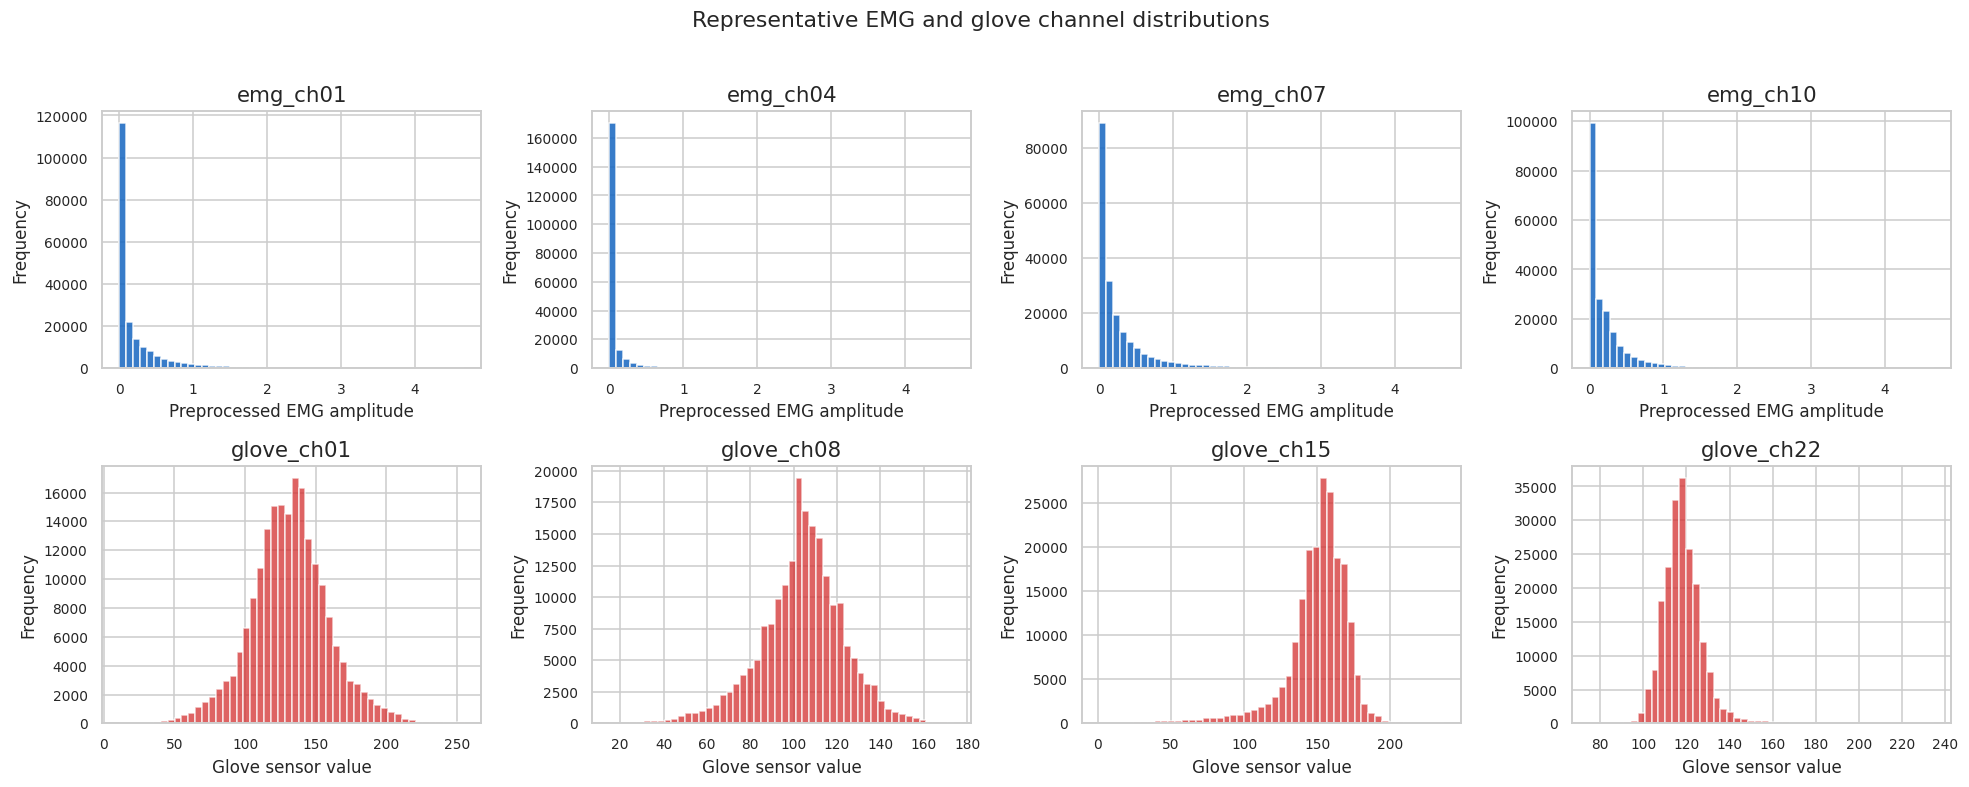

In [9]:
selected_emg = [emg_columns[i] for i in np.linspace(0, len(emg_columns)-1, 4, dtype=int)]
selected_glove = [glove_columns[i] for i in np.linspace(0, len(glove_columns)-1, 4, dtype=int)]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, column in zip(axes[0], selected_emg):
    ax.hist(raw_df[column], bins=50, color=EMG_COLOR, alpha=0.85)
    ax.set_title(column)
    ax.set_xlabel("Preprocessed EMG amplitude")
    ax.set_ylabel("Frequency")
for ax, column in zip(axes[1], selected_glove):
    ax.hist(raw_df[column], bins=50, color=GLOVE_COLOR, alpha=0.75)
    ax.set_title(column)
    ax.set_xlabel("Glove sensor value")
    ax.set_ylabel("Frequency")
fig.suptitle("Representative EMG and glove channel distributions", y=1.02)
plt.tight_layout()
plt.show()


## C2. Rest versus movement

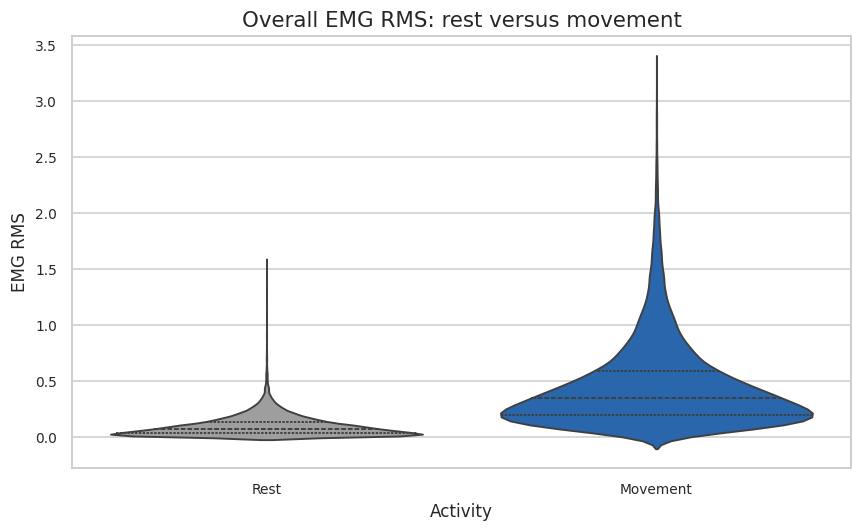

,mean,median,std
activity,,,
Movement,0.4580,0.3457,0.3859
Rest,0.1007,0.0756,0.0953


In [10]:
plot_sample = raw_df.sample(min(50000, len(raw_df)), random_state=RANDOM_STATE)
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=plot_sample,
    x="activity",
    y="emg_rms",
    order=["Rest", "Movement"],
    inner="quartile",
    palette={"Rest": "#9E9E9E", "Movement": EMG_COLOR},
)
plt.title("Overall EMG RMS: rest versus movement")
plt.xlabel("Activity")
plt.ylabel("EMG RMS")
plt.tight_layout()
plt.show()

display(raw_df.groupby("activity")["emg_rms"].agg(["mean", "median", "std"]).round(4))


# D. Movement and exercise coverage

The movement labels restart inside each exercise, so the notebook converts them to correct global labels 1–52. Rest is reported separately.

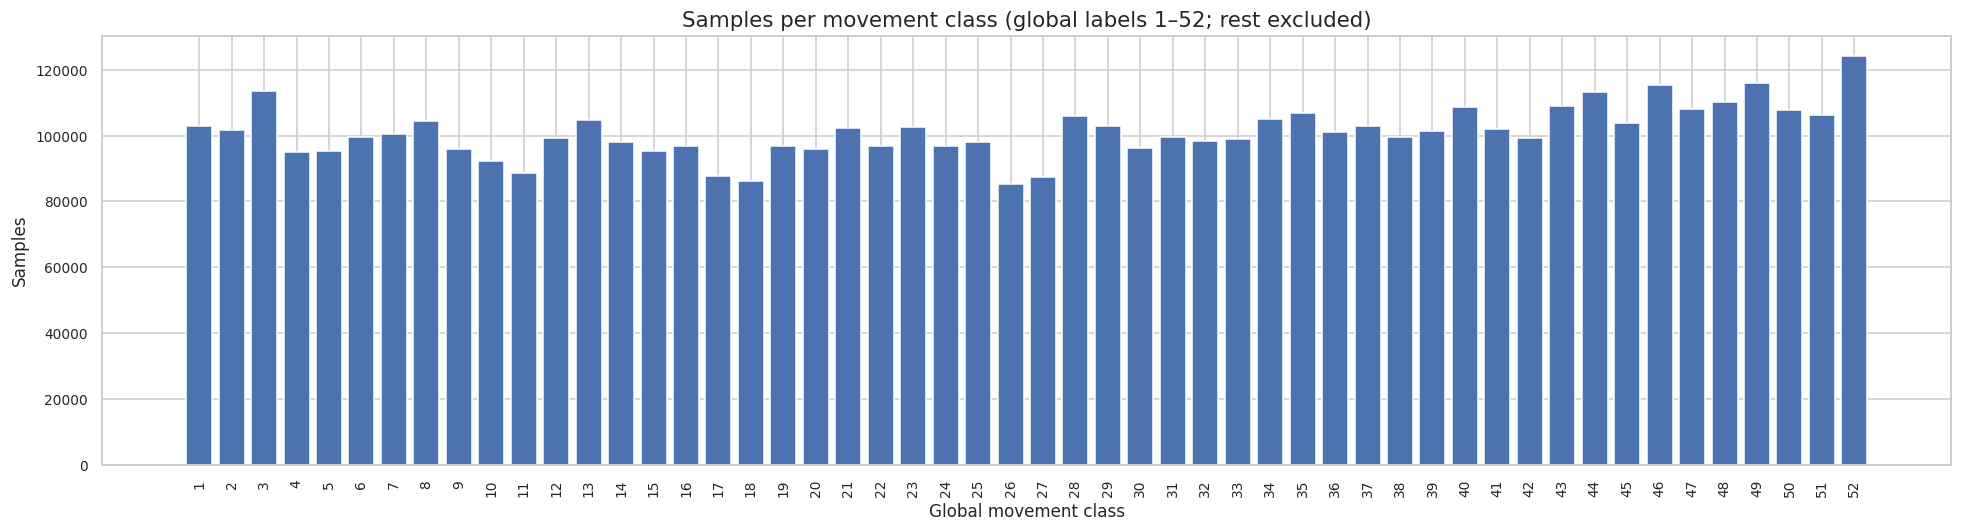

Rest samples: 7,290,845
Movement classes present: 52/52
Movement count min/median/max: 85,442 / 100,774 / 124,115


,exercise,Files,Samples,Duration_minutes
0,1,27,2731393,455.23
1,2,27,3868568,644.76
2,3,27,5953650,992.28


In [11]:
movement_rows = []
for (exercise, local_label), count in movement_counter.items():
    movement_rows.append({
        "exercise": exercise,
        "local_label": local_label,
        "global_label": global_movement_label(exercise, local_label),
        "movement": movement_name(exercise, local_label),
        "samples": count,
    })
movement_df = pd.DataFrame(movement_rows).sort_values("global_label")

plt.figure(figsize=(18, 5))
plt.bar(movement_df.global_label.astype(str), movement_df.samples, color="#4C72B0")
plt.title("Samples per movement class (global labels 1–52; rest excluded)")
plt.xlabel("Global movement class")
plt.ylabel("Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Rest samples: {rest_samples:,}")
print(f"Movement classes present: {movement_df.global_label.nunique()}/52")
print(
    "Movement count min/median/max: "
    f"{movement_df.samples.min():,} / {int(movement_df.samples.median()):,} / {movement_df.samples.max():,}"
)

exercise_summary = inventory_df.groupby("exercise").agg(
    Files=("File", "count"),
    Samples=("Samples", "sum"),
    Duration_minutes=("Duration_min", "sum"),
).reset_index()
display(exercise_summary.round(2))


# E. Temporal signal behaviour

## E1. Synchronized EMG, glove, and movement annotation

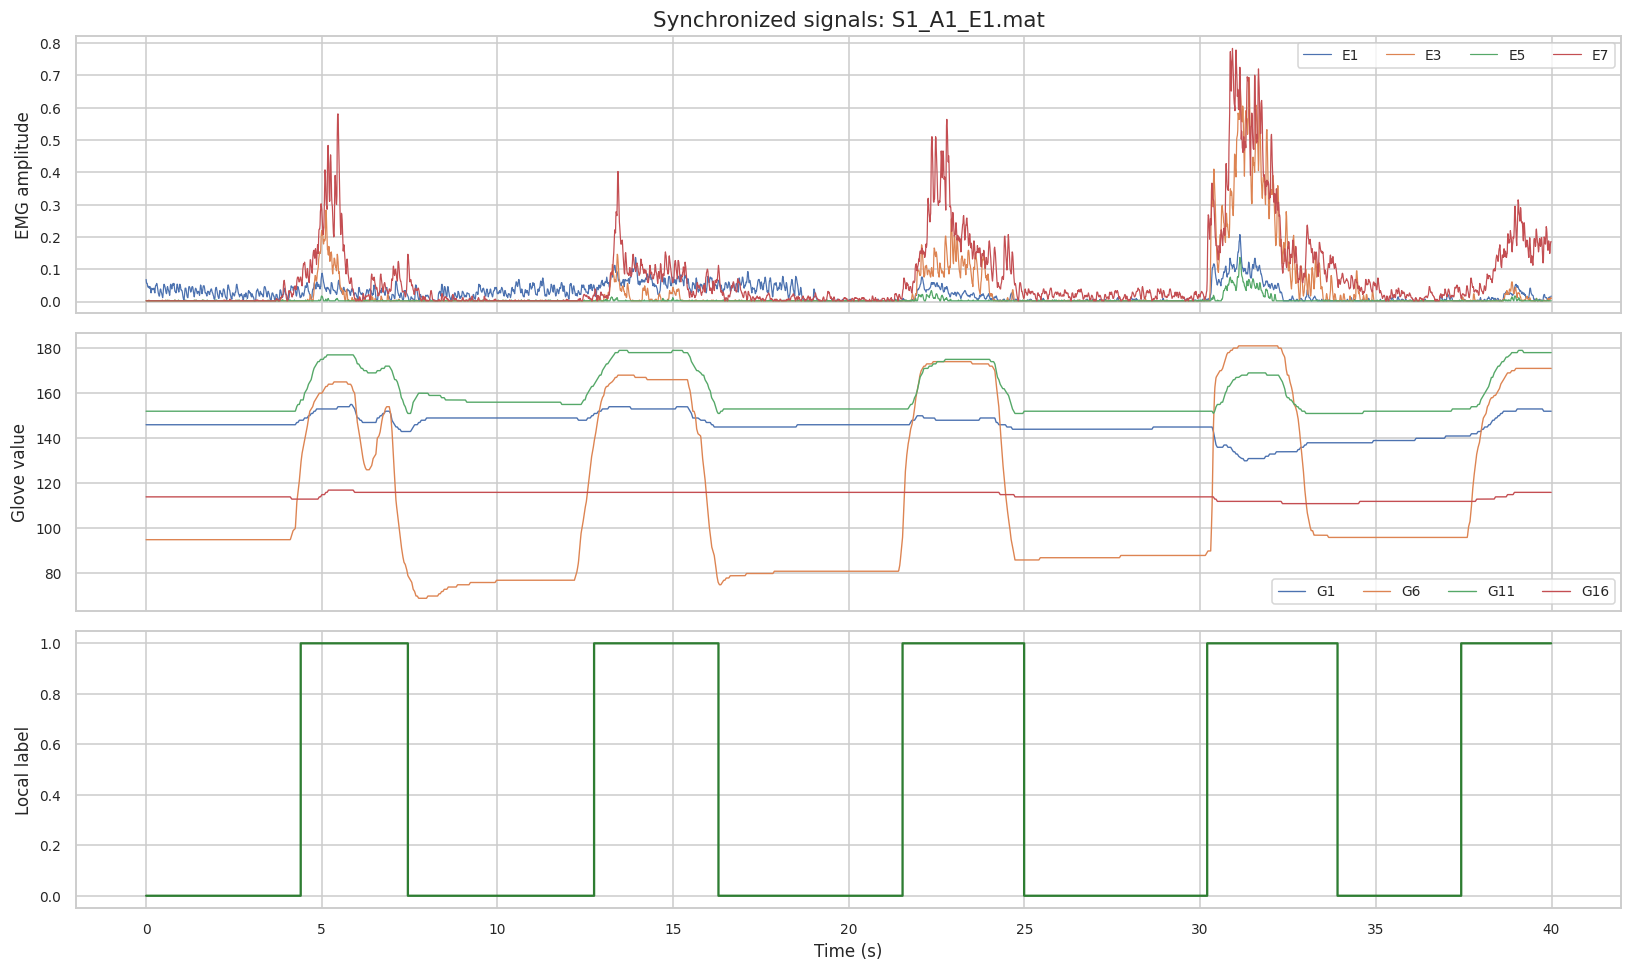

In [12]:
example_path = mat_files[0]
example = load_db1(example_path)
show_seconds = 40
stop = min(len(example["emg"]), show_seconds * FS)
time = np.arange(stop) / FS

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for channel in [0, 2, 4, 6]:
    axes[0].plot(time, example["emg"][:stop, channel], lw=0.8, label=f"E{channel+1}")
axes[0].set_title(f"Synchronized signals: {example_path.name}")
axes[0].set_ylabel("EMG amplitude")
axes[0].legend(ncol=4)

for channel in [0, 5, 10, 15]:
    axes[1].plot(time, example["glove"][:stop, channel], lw=0.9, label=f"G{channel+1}")
axes[1].set_ylabel("Glove value")
axes[1].legend(ncol=4)

axes[2].step(time, example["restimulus"][:stop], where="post", color=LABEL_COLOR)
axes[2].set_ylabel("Local label")
axes[2].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


## E2. EMG envelope versus the most related glove sensor

The two signals use **clearly different colours and matching coloured axes**. The glove sensor is selected by the strongest absolute Pearson correlation in the displayed file. This is exploratory association, not regression performance.

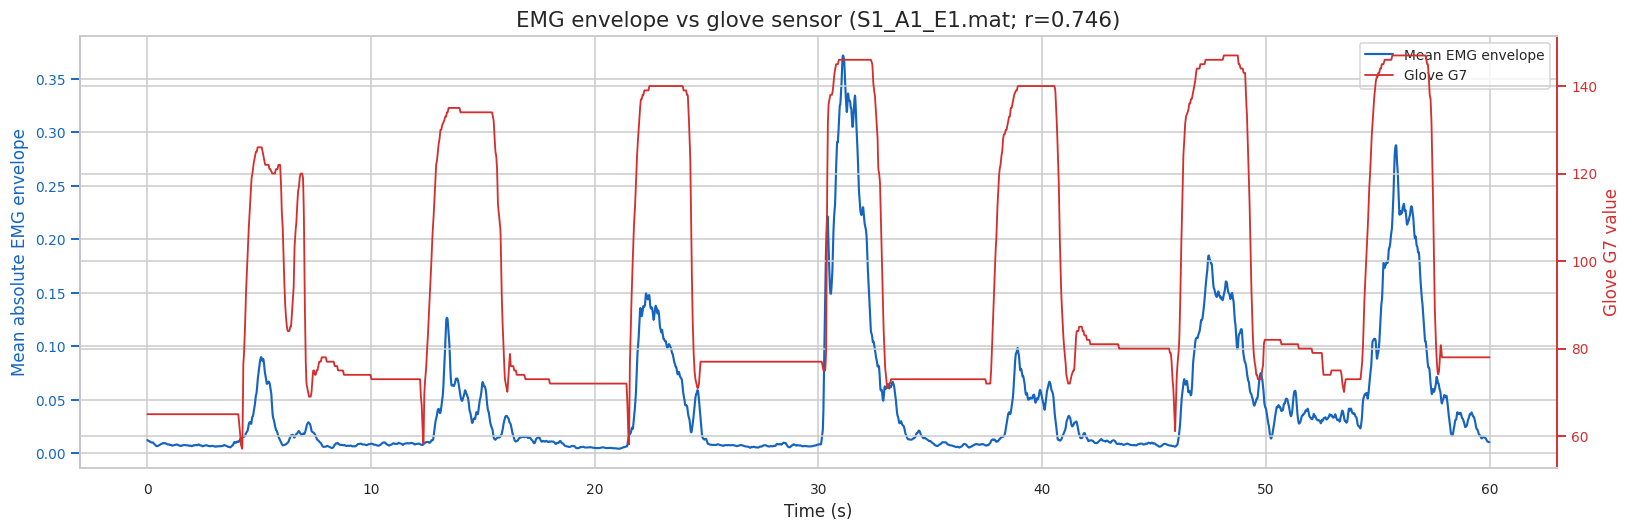

Selected glove sensor: G7; correlation with EMG envelope = 0.746


In [13]:
relation_seconds = 60
relation_stop = min(len(example["emg"]), relation_seconds * FS)
relation_time = np.arange(relation_stop) / FS

mean_abs_emg = np.mean(np.abs(example["emg"][:relation_stop]), axis=1)
emg_envelope = (
    pd.Series(mean_abs_emg)
    .rolling(WINDOW_SAMPLES, center=True, min_periods=1)
    .mean()
    .to_numpy()
)
example_glove = example["glove"][:relation_stop]
correlations = np.array([
    np.corrcoef(emg_envelope, example_glove[:, channel])[0, 1]
    for channel in range(example_glove.shape[1])
])
best_glove = int(np.nanargmax(np.abs(correlations)))
best_r = float(correlations[best_glove])

fig, axis_emg = plt.subplots(figsize=(15, 5))
axis_glove = axis_emg.twinx()

emg_line = axis_emg.plot(
    relation_time, emg_envelope,
    color=EMG_COLOR, linewidth=1.4,
    label="Mean EMG envelope",
)
glove_line = axis_glove.plot(
    relation_time, example_glove[:, best_glove],
    color=GLOVE_COLOR, linewidth=1.2,
    label=f"Glove G{best_glove+1}",
)

axis_emg.set_title(
    f"EMG envelope vs glove sensor ({example_path.name}; r={best_r:.3f})"
)
axis_emg.set_xlabel("Time (s)")
axis_emg.set_ylabel("Mean absolute EMG envelope", color=EMG_COLOR)
axis_glove.set_ylabel(f"Glove G{best_glove+1} value", color=GLOVE_COLOR)
axis_emg.tick_params(axis="y", colors=EMG_COLOR)
axis_glove.tick_params(axis="y", colors=GLOVE_COLOR)
axis_emg.spines["left"].set_color(EMG_COLOR)
axis_glove.spines["right"].set_color(GLOVE_COLOR)

lines = emg_line + glove_line
axis_emg.legend(lines, [line.get_label() for line in lines], loc="upper right")
plt.tight_layout()
plt.show()

print(
    f"Selected glove sensor: G{best_glove+1}; "
    f"correlation with EMG envelope = {best_r:.3f}"
)


## E3. Repetition consistency within one subject

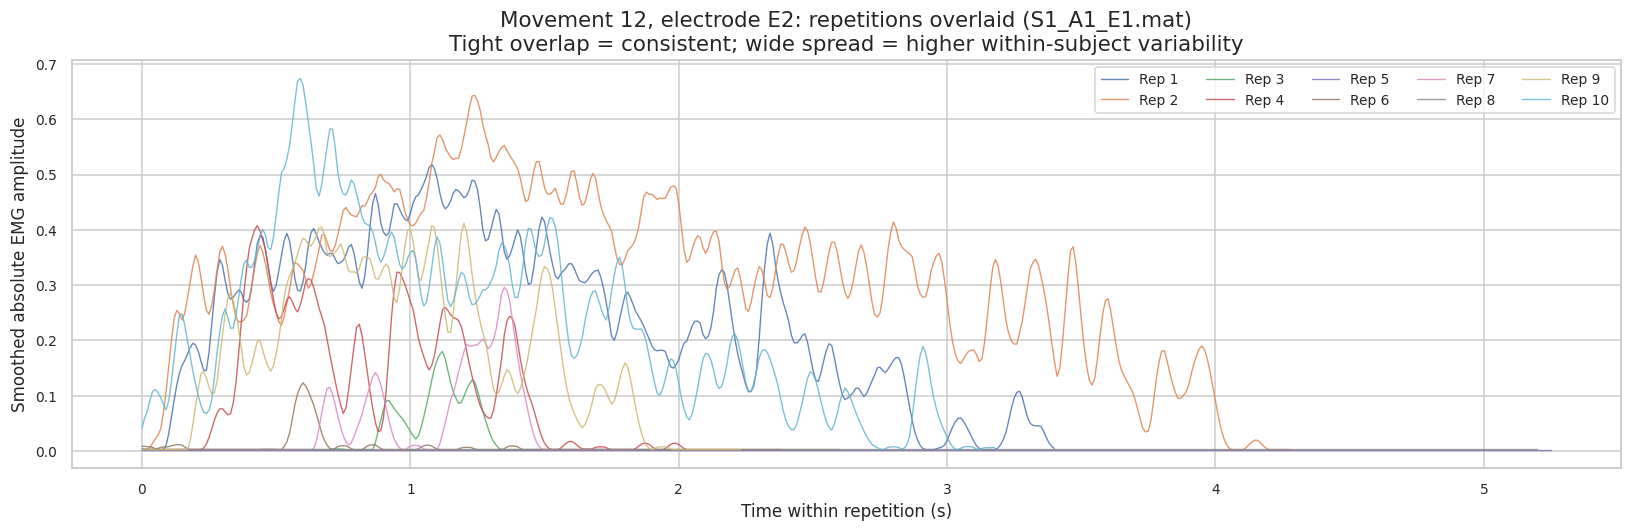

,Repetition,Duration_s,Mean_abs_EMG,Peak_abs_EMG
0,1,3.41,0.2384,0.5181
1,2,4.29,0.3103,0.6435
2,3,1.89,0.0221,0.1797
3,4,2.39,0.1019,0.4077
4,5,5.26,0.0024,0.0024
5,6,2.61,0.0075,0.1231
6,7,1.85,0.0448,0.2959
7,8,5.21,0.0024,0.0024
8,9,2.24,0.1770,0.4121
9,10,3.19,0.2248,0.6738


In [14]:
repetition_path = next(
    path for path in mat_files
    if parse_file_ids(path)["subject"] == 1 and parse_file_ids(path)["exercise"] == 1
)
rep_data = load_db1(repetition_path)
rep_labels = rep_data["restimulus"].astype(int)
rep_numbers = rep_data["rerepetition"].astype(int)
rep_emg = np.asarray(rep_data["emg"])

movement_candidates = []
for movement in sorted(set(rep_labels) - {0}):
    reps = np.unique(rep_numbers[(rep_labels == movement) & (rep_numbers > 0)])
    movement_candidates.append((len(reps), int(movement)))
_, selected_movement = max(movement_candidates)

movement_mask = rep_labels == selected_movement
selected_electrode = int(np.argmax(np.sqrt(np.mean(rep_emg[movement_mask] ** 2, axis=0))))

plt.figure(figsize=(15, 5))
duration_rows = []
for repetition in sorted(np.unique(rep_numbers[(rep_labels == selected_movement) & (rep_numbers > 0)])):
    indices = np.flatnonzero((rep_labels == selected_movement) & (rep_numbers == repetition))
    runs = contiguous_runs(indices)
    if not runs:
        continue
    segment = max(runs, key=len)
    signal = np.abs(rep_emg[segment, selected_electrode])
    signal = pd.Series(signal).rolling(5, center=True, min_periods=1).mean().to_numpy()
    local_time = np.arange(len(signal)) / FS
    plt.plot(local_time, signal, lw=0.9, alpha=0.85, label=f"Rep {int(repetition)}")
    duration_rows.append({
        "Repetition": int(repetition),
        "Duration_s": len(signal) / FS,
        "Mean_abs_EMG": float(signal.mean()),
        "Peak_abs_EMG": float(signal.max()),
    })

plt.title(
    f"Movement {selected_movement}, electrode E{selected_electrode+1}: "
    f"repetitions overlaid ({repetition_path.name})\n"
    "Tight overlap = consistent; wide spread = higher within-subject variability"
)
plt.xlabel("Time within repetition (s)")
plt.ylabel("Smoothed absolute EMG amplitude")
plt.legend(ncol=5)
plt.tight_layout()
plt.show()

duration_df = pd.DataFrame(duration_rows)
display(duration_df.round(4))


# F. Between-subject variability

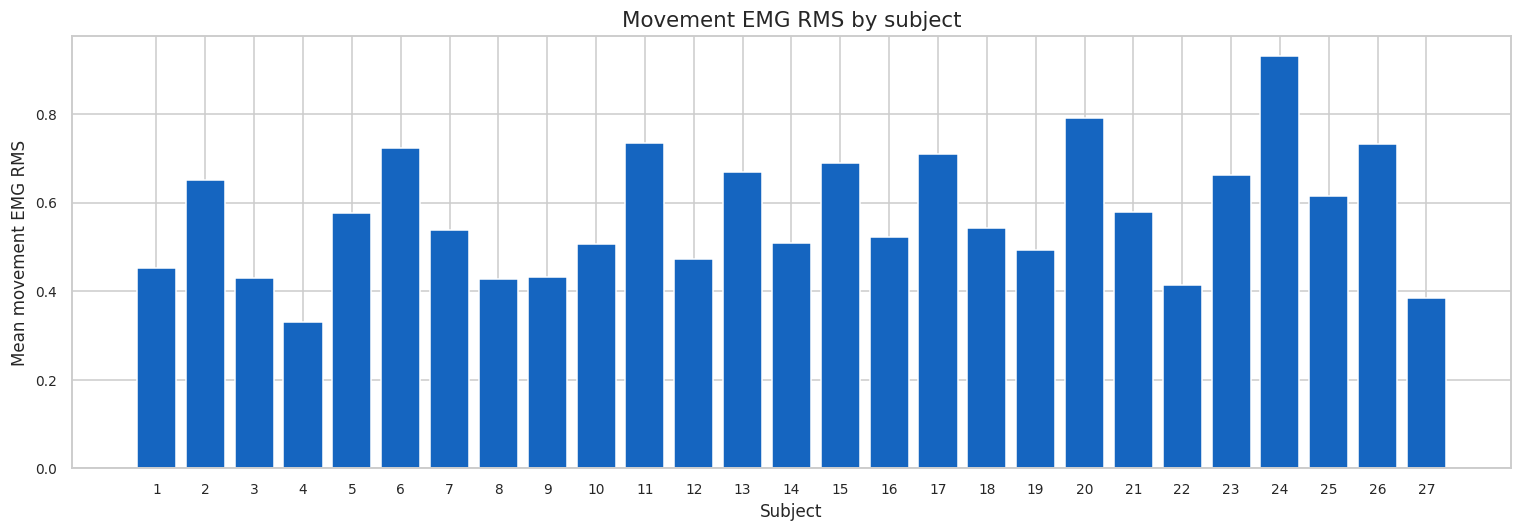

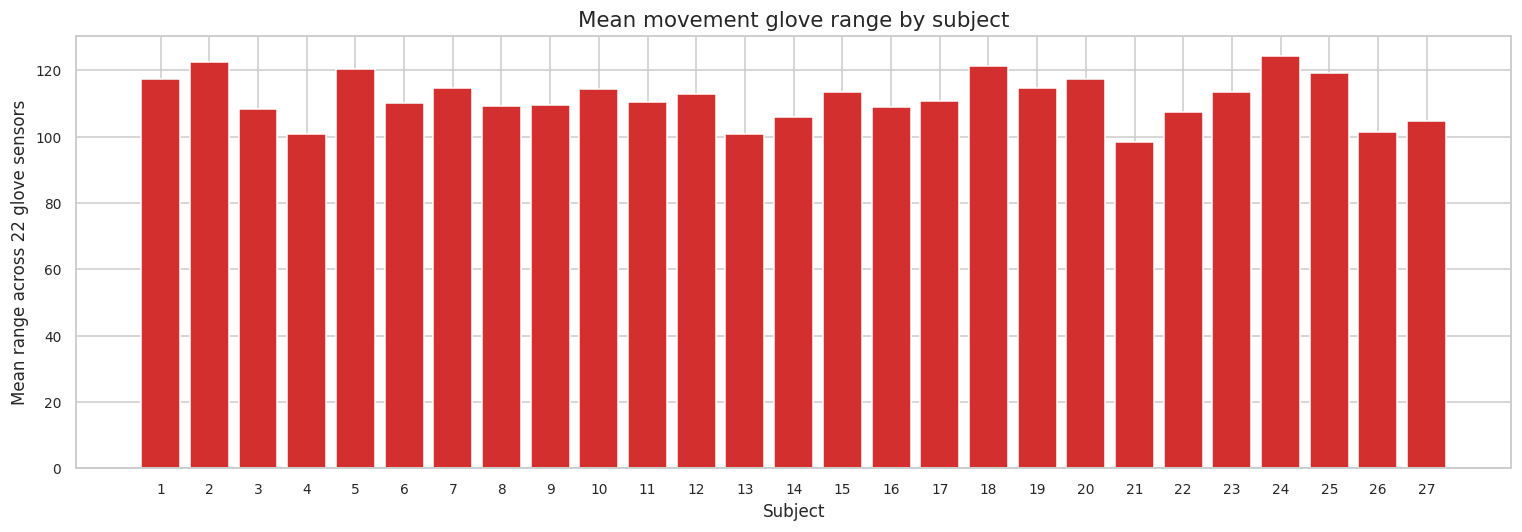

Between-subject EMG RMS coefficient of variation: 24.9%
Between-subject glove-range coefficient of variation: 6.2%


In [15]:
subject_variability = inventory_df.groupby("subject").agg(
    Movement_EMG_RMS=("Movement_EMG_RMS", "mean"),
    Movement_glove_range=("Movement_glove_range", "mean"),
    Total_samples=("Samples", "sum"),
).reset_index()

plt.figure(figsize=(14, 5))
plt.bar(subject_variability.subject.astype(str), subject_variability.Movement_EMG_RMS, color=EMG_COLOR)
plt.title("Movement EMG RMS by subject")
plt.xlabel("Subject")
plt.ylabel("Mean movement EMG RMS")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(subject_variability.subject.astype(str), subject_variability.Movement_glove_range, color=GLOVE_COLOR)
plt.title("Mean movement glove range by subject")
plt.xlabel("Subject")
plt.ylabel("Mean range across 22 glove sensors")
plt.tight_layout()
plt.show()

emg_cv = 100 * subject_variability.Movement_EMG_RMS.std() / subject_variability.Movement_EMG_RMS.mean()
glove_cv = 100 * subject_variability.Movement_glove_range.std() / subject_variability.Movement_glove_range.mean()
print(f"Between-subject EMG RMS coefficient of variation: {emg_cv:.1f}%")
print(f"Between-subject glove-range coefficient of variation: {glove_cv:.1f}%")


# G. Correlation and EMG–glove relationships

All heatmaps display numerical values inside the cells.

## G1. EMG channel correlation

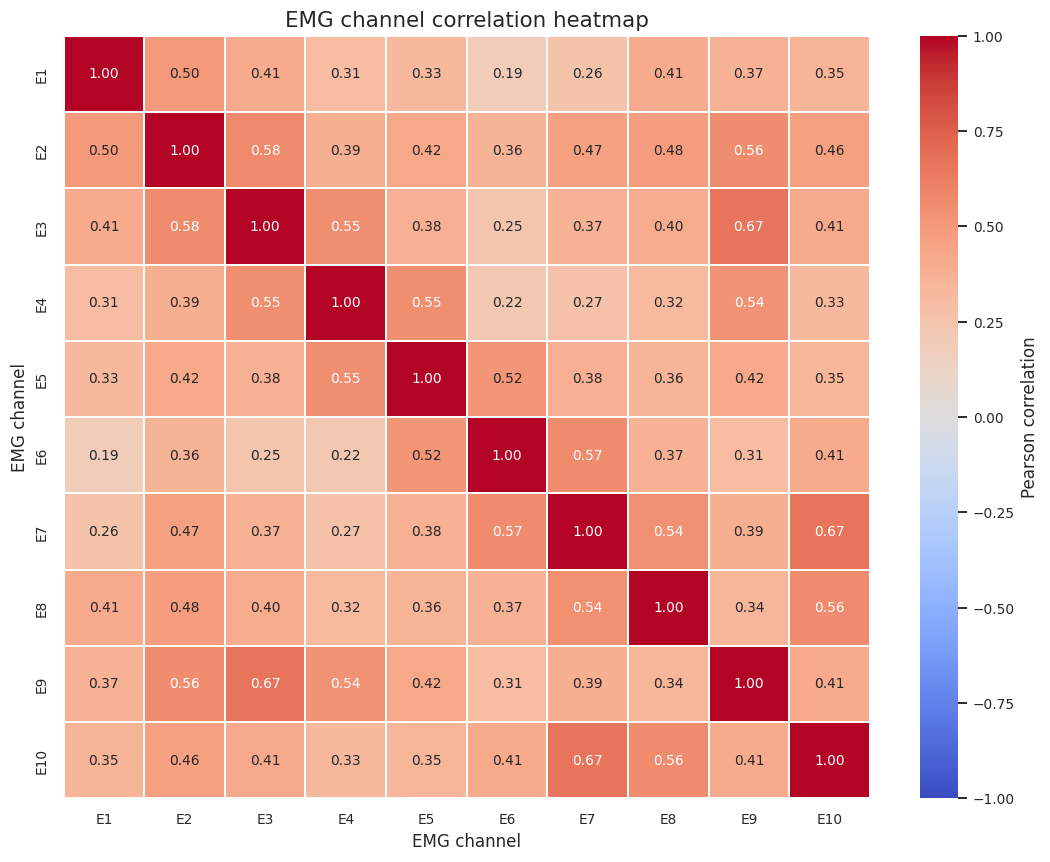

Strongest EMG pair: emg_ch03 and emg_ch09 (r=0.671)
EMG pairs with |r| ≥ 0.95: 0


In [16]:
emg_corr = raw_df[emg_columns].corr()
annotated_heatmap(
    emg_corr,
    title="EMG channel correlation heatmap",
    xlabels=[f"E{i+1}" for i in range(len(emg_columns))],
    ylabels=[f"E{i+1}" for i in range(len(emg_columns))],
    xlabel="EMG channel",
    ylabel="EMG channel",
    figsize=(10, 8),
    font_size=9,
)

emg_upper = emg_corr.where(np.triu(np.ones(emg_corr.shape), k=1).astype(bool)).stack()
emg_pair = emg_upper.abs().idxmax()
print(f"Strongest EMG pair: {emg_pair[0]} and {emg_pair[1]} (r={emg_corr.loc[emg_pair]:.3f})")
print("EMG pairs with |r| ≥ 0.95:", int((emg_upper.abs() >= 0.95).sum()))


## G2. Glove channel correlation

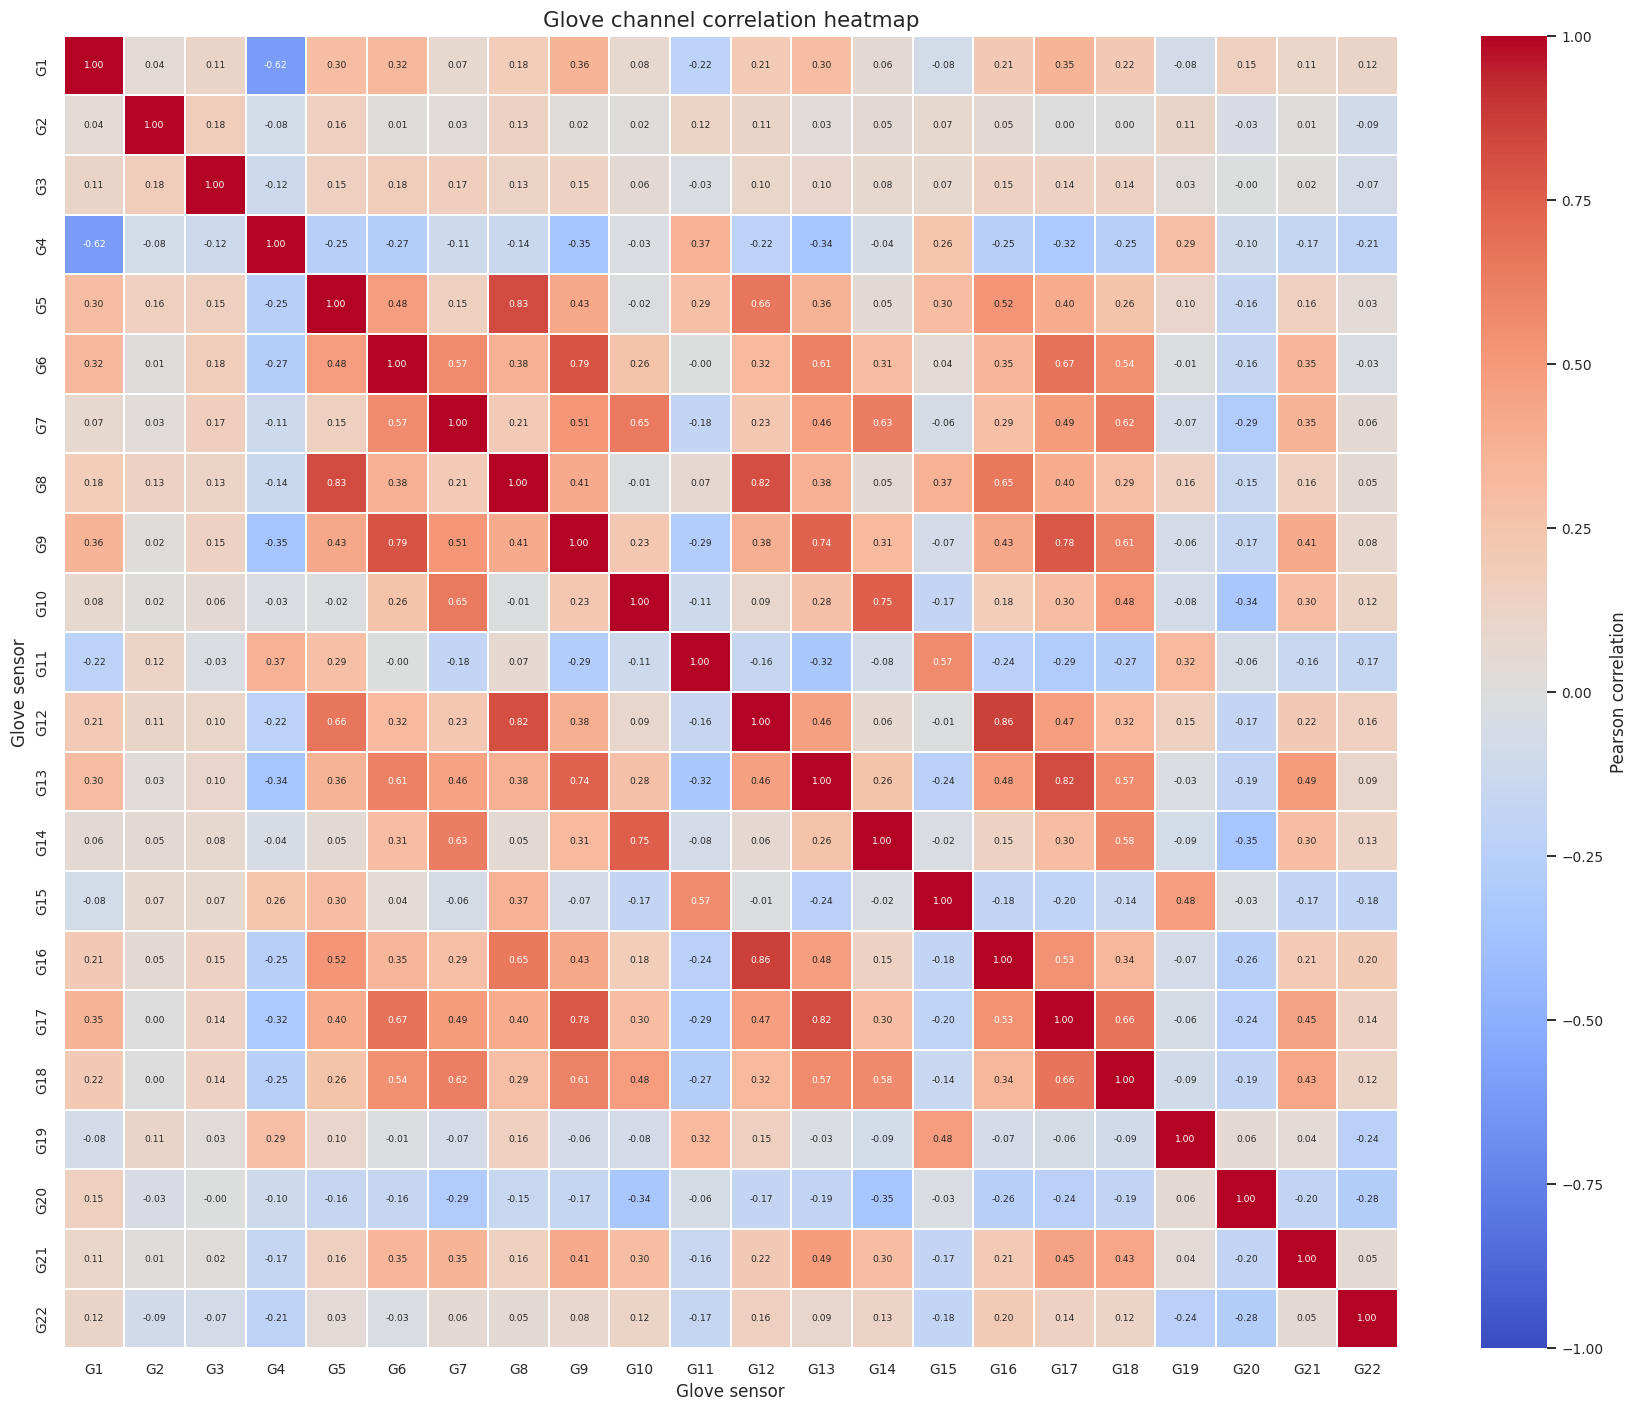

Strongest glove pair: glove_ch12 and glove_ch16 (r=0.862)
Glove pairs with |r| ≥ 0.95: 0


In [17]:
glove_corr = raw_df[glove_columns].corr()
annotated_heatmap(
    glove_corr,
    title="Glove channel correlation heatmap",
    xlabels=[f"G{i+1}" for i in range(len(glove_columns))],
    ylabels=[f"G{i+1}" for i in range(len(glove_columns))],
    xlabel="Glove sensor",
    ylabel="Glove sensor",
    figsize=(16, 13),
    font_size=6,
)

glove_upper = glove_corr.where(np.triu(np.ones(glove_corr.shape), k=1).astype(bool)).stack()
glove_pair = glove_upper.abs().idxmax()
print(f"Strongest glove pair: {glove_pair[0]} and {glove_pair[1]} (r={glove_corr.loc[glove_pair]:.3f})")
print("Glove pairs with |r| ≥ 0.95:", int((glove_upper.abs() >= 0.95).sum()))


## G3. EMG envelope–glove correlation

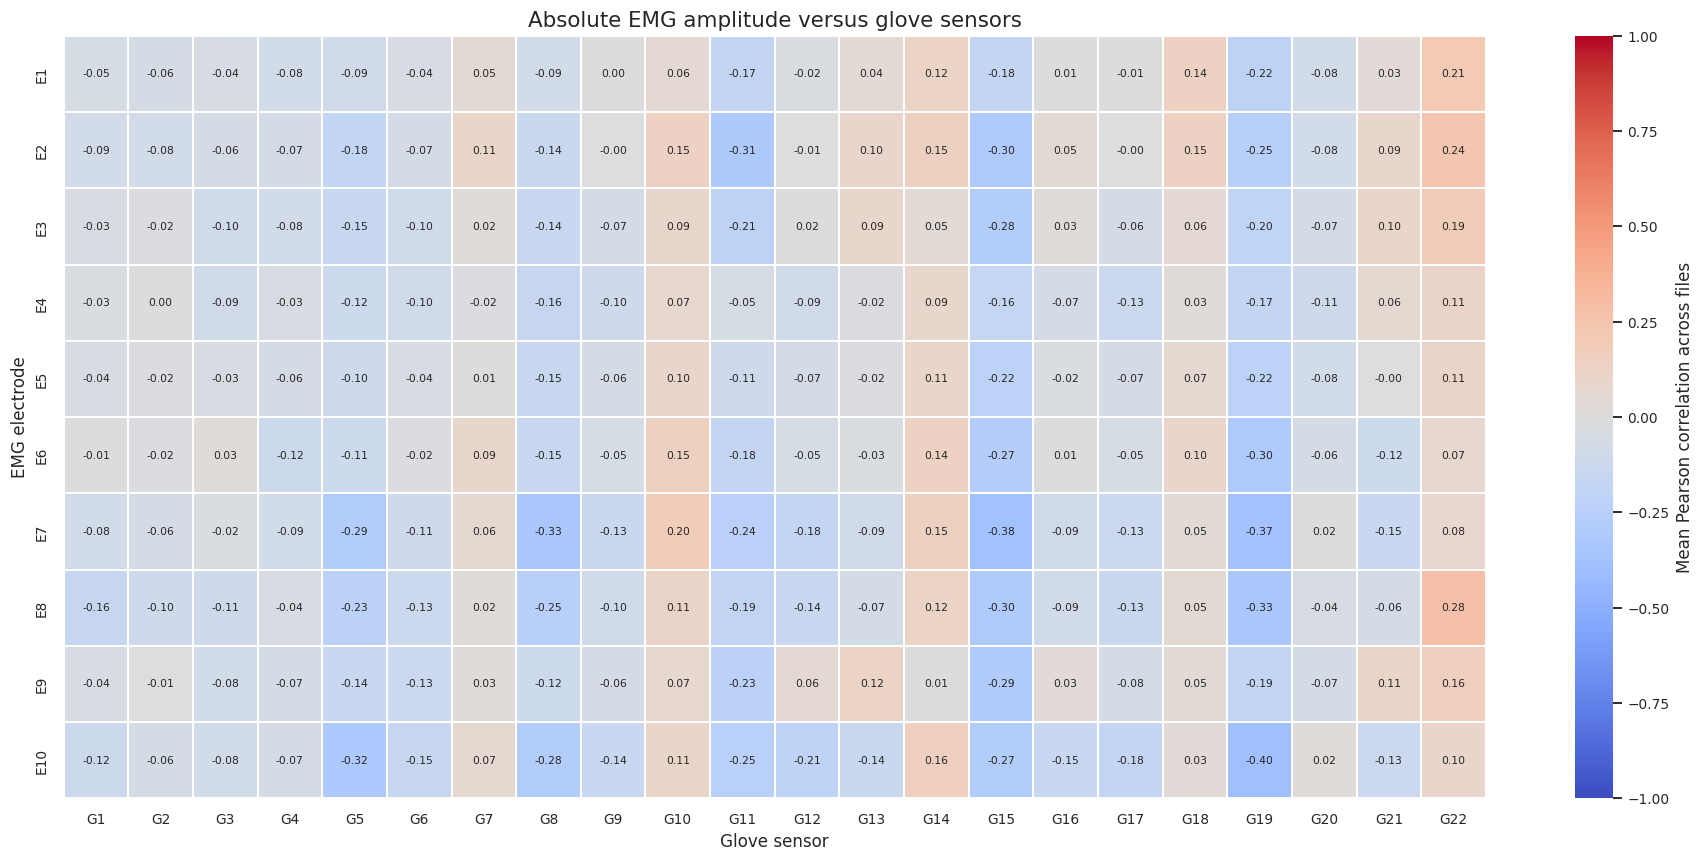

Strongest EMG–glove relationships


,EMG,Glove,Mean_r
216,emg_ch10,glove_ch19,-0.397
146,emg_ch07,glove_ch15,-0.381
150,emg_ch07,glove_ch19,-0.373
172,emg_ch08,glove_ch19,-0.334
139,emg_ch07,glove_ch08,-0.329
202,emg_ch10,glove_ch05,-0.317
32,emg_ch02,glove_ch11,-0.310
128,emg_ch06,glove_ch19,-0.303
168,emg_ch08,glove_ch15,-0.301
36,emg_ch02,glove_ch15,-0.298


Mean |r|: 0.110
Maximum |r|: 0.397


In [18]:
file_correlations = []
for file_path in mat_files:
    data = load_db1(file_path)
    emg_envelopes = np.abs(np.asarray(data["emg"]))
    glove = np.asarray(data["glove"])
    matrix = np.column_stack([emg_envelopes, glove])
    corr = np.corrcoef(matrix.T)[:emg_envelopes.shape[1], emg_envelopes.shape[1]:]
    file_correlations.append(corr)

mean_emg_glove_corr = np.nanmean(file_correlations, axis=0)
annotated_heatmap(
    mean_emg_glove_corr,
    title="Absolute EMG amplitude versus glove sensors",
    xlabels=[f"G{i+1}" for i in range(mean_emg_glove_corr.shape[1])],
    ylabels=[f"E{i+1}" for i in range(mean_emg_glove_corr.shape[0])],
    xlabel="Glove sensor",
    ylabel="EMG electrode",
    figsize=(17, 8),
    font_size=7,
    cbar_label="Mean Pearson correlation across files",
)

relationship_rows = []
for i, emg_name in enumerate(emg_columns):
    for j, glove_name in enumerate(glove_columns):
        relationship_rows.append({
            "EMG": emg_name,
            "Glove": glove_name,
            "Mean_r": mean_emg_glove_corr[i, j],
            "Absolute_r": abs(mean_emg_glove_corr[i, j]),
        })
relationship_df = pd.DataFrame(relationship_rows).sort_values("Absolute_r", ascending=False)
print("Strongest EMG–glove relationships")
display(relationship_df.head(15).drop(columns="Absolute_r").round(3))
print(f"Mean |r|: {relationship_df.Absolute_r.mean():.3f}")
print(f"Maximum |r|: {relationship_df.Absolute_r.max():.3f}")


# H. Window-level EDA for future continuous pose regression

Each 200 ms window produces 40 EMG features: MAV, RMS, waveform length, and variance for 10 electrodes. The synchronized mean of the 22 glove channels is stored as a continuous pose summary. This section only explores the resulting tables; it does not train a model.

In [19]:
FEATURE_TYPES = ["MAV", "RMS", "WL", "VAR"]

def extract_emg_features(window):
    return np.concatenate([
        np.mean(np.abs(window), axis=0),
        np.sqrt(np.mean(window ** 2, axis=0)),
        np.sum(np.abs(np.diff(window, axis=0)), axis=0),
        np.var(window, axis=0),
    ])

feature_names = [
    f"{feature}_E{channel+1}"
    for feature in FEATURE_TYPES
    for channel in range(len(emg_columns))
]
target_names = [f"target_G{channel+1}" for channel in range(len(glove_columns))]

feature_rows, target_rows, metadata_rows = [], [], []
for file_number, file_path in enumerate(mat_files):
    data = load_db1(file_path)
    ids = parse_file_ids(file_path)
    emg = np.asarray(data["emg"])
    glove = np.asarray(data["glove"])
    labels = data["restimulus"].astype(int)
    rerepetitions = data["rerepetition"].astype(int)

    starts = np.arange(0, len(emg) - WINDOW_SAMPLES + 1, WINDOW_STEP)
    local_rng = np.random.default_rng(RANDOM_STATE + file_number)
    starts = local_rng.permutation(starts)

    accepted = 0
    for start in starts:
        segment_labels = labels[start:start+WINDOW_SAMPLES]
        values, counts = np.unique(segment_labels, return_counts=True)
        majority_idx = int(np.argmax(counts))
        majority_label = int(values[majority_idx])
        purity = counts[majority_idx] / WINDOW_SAMPLES
        if purity < WINDOW_PURITY:
            continue

        stop = start + WINDOW_SAMPLES
        center = start + WINDOW_SAMPLES // 2
        feature_rows.append(extract_emg_features(emg[start:stop]))
        target_rows.append(glove[start:stop].mean(axis=0))
        metadata_rows.append({
            "subject": int(ids["subject"]),
            "exercise": int(ids["exercise"]),
            "local_label": majority_label,
            "global_label": global_movement_label(ids["exercise"], majority_label),
            "movement": movement_name(ids["exercise"], majority_label),
            "activity": "Rest" if majority_label == 0 else "Movement",
            "rerepetition": int(rerepetitions[center]),
            "file": file_path.name,
            "window_start": int(start),
            "window_center_s": center / FS,
            "label_purity": float(purity),
        })
        accepted += 1
        if accepted >= MAX_WINDOWS_PER_FILE:
            break

window_X = pd.DataFrame(feature_rows, columns=feature_names)
window_G = pd.DataFrame(target_rows, columns=target_names)
window_meta = pd.DataFrame(metadata_rows)

window_summary = pd.DataFrame({
    "Item": [
        "Windows", "EMG features", "Glove targets", "Subjects", "Exercises",
        "Missing feature values", "Missing target values", "Duplicate feature rows",
        "Median label purity", "Movement-window percentage",
    ],
    "Result": [
        len(window_X), window_X.shape[1], window_G.shape[1],
        window_meta.subject.nunique(), window_meta.exercise.nunique(),
        int(window_X.isna().sum().sum()), int(window_G.isna().sum().sum()),
        int(window_X.duplicated().sum()),
        f"{window_meta.label_purity.median()*100:.1f}%",
        f"{window_meta.activity.eq('Movement').mean()*100:.1f}%",
    ],
})
display(window_summary)


,Item,Result
0,Windows,28350
1,EMG features,40
2,Glove targets,22
3,Subjects,27
4,Exercises,3
5,Missing feature values,0
6,Missing target values,0
7,Duplicate feature rows,33
8,Median label purity,100.0%
9,Movement-window percentage,42.2%


## H1. Glove target quality and feature relationships

Glove target statistics


,mean,median,std,min,q25,q75,max,skewness,kurtosis,outlier_%
target_G1,131.943,132.000,27.600,13.000,115.000,148.730,255.000,0.101,0.750,2.564
target_G2,111.570,111.000,15.710,1.000,102.294,120.000,216.362,0.297,2.563,3.679
target_G3,111.029,112.000,14.524,27.901,104.823,118.000,186.000,-0.257,2.922,8.127
target_G4,132.334,131.000,15.280,69.701,122.000,142.000,190.000,0.266,0.042,0.875
target_G5,116.667,119.000,19.963,22.954,106.000,129.000,197.214,-0.583,1.070,3.672
target_G6,91.054,88.833,34.606,2.371,65.000,115.000,205.000,0.355,-0.312,0.212
target_G7,85.402,81.000,20.731,1.000,74.000,91.000,255.000,1.868,6.909,8.339
target_G8,104.003,105.000,19.631,13.278,93.535,115.184,172.000,-0.374,1.145,4.155
target_G9,102.554,103.000,31.822,22.092,77.433,125.000,200.000,0.135,-0.544,0.028
target_G10,77.355,75.000,15.011,1.000,69.000,83.389,196.635,1.004,5.987,5.591


Near-constant glove targets: None


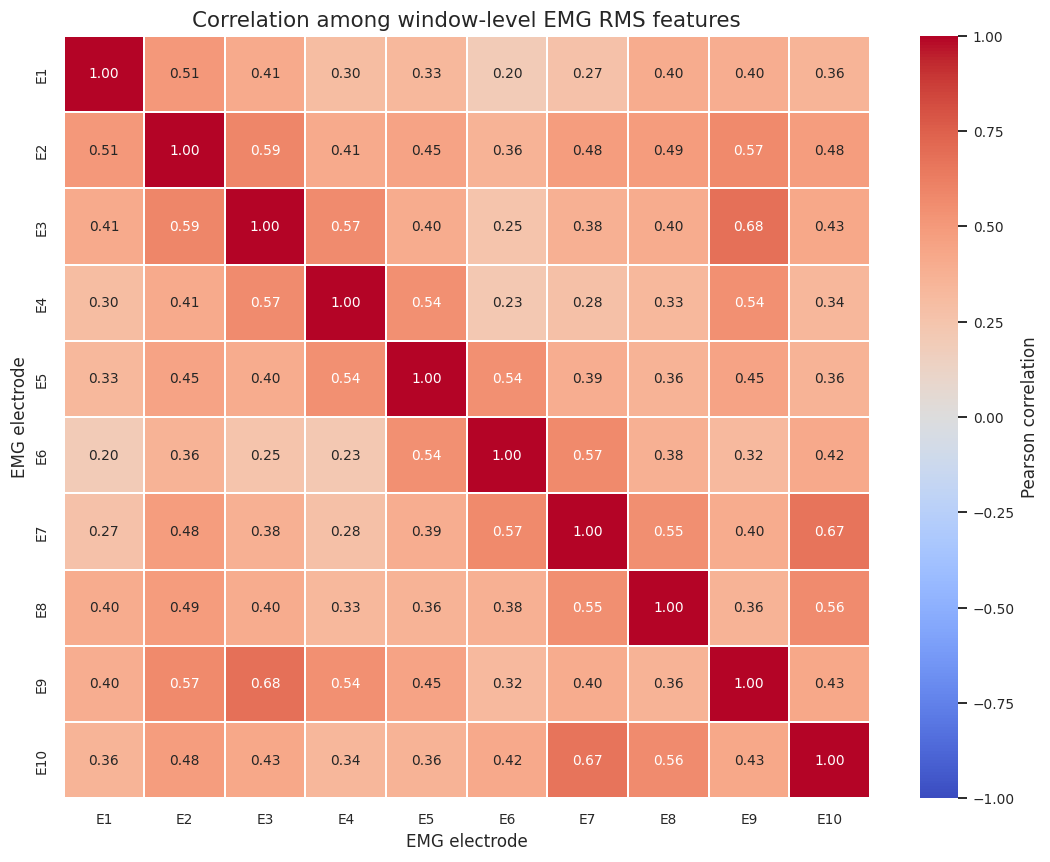

Feature pairs with |r| ≥ 0.95: 10


,level_0,level_1,r
0,MAV_E7,RMS_E7,1.0
1,MAV_E10,RMS_E10,1.0
2,MAV_E8,RMS_E8,1.0
3,MAV_E1,RMS_E1,1.0
4,MAV_E6,RMS_E6,1.0
5,MAV_E4,RMS_E4,1.0
6,MAV_E3,RMS_E3,1.0
7,MAV_E5,RMS_E5,1.0
8,MAV_E2,RMS_E2,1.0
9,MAV_E9,RMS_E9,1.0


Strongest feature–target correlations


,EMG_feature,Glove_target,r
422,RMS_E10,target_G5,-0.360
202,MAV_E10,target_G5,-0.360
642,WL_E10,target_G5,-0.351
139,MAV_E7,target_G8,-0.322
359,RMS_E7,target_G8,-0.321
436,RMS_E10,target_G19,-0.307
216,MAV_E10,target_G19,-0.306
136,MAV_E7,target_G5,-0.305
356,RMS_E7,target_G5,-0.304
205,MAV_E10,target_G8,-0.302


In [20]:
target_stats = describe_columns(window_G, target_names)
print("Glove target statistics")
display(target_stats.round(3))
near_constant_targets = target_stats.index[target_stats["std"] < 1e-6].tolist()
print("Near-constant glove targets:", near_constant_targets if near_constant_targets else "None")

rms_columns = [f"RMS_E{i+1}" for i in range(len(emg_columns))]
rms_corr = window_X[rms_columns].corr()
annotated_heatmap(
    rms_corr,
    title="Correlation among window-level EMG RMS features",
    xlabels=[f"E{i+1}" for i in range(len(rms_columns))],
    ylabels=[f"E{i+1}" for i in range(len(rms_columns))],
    xlabel="EMG electrode",
    ylabel="EMG electrode",
    figsize=(10, 8),
    font_size=9,
)

redundant_features = high_correlation_pairs(window_X, threshold=0.95)
print(f"Feature pairs with |r| ≥ 0.95: {len(redundant_features)}")
if len(redundant_features):
    display(redundant_features.head(15).rename("r").reset_index().round(3))

feature_target_corr = pd.concat([window_X, window_G], axis=1).corr().loc[feature_names, target_names]
association_rows = []
for feature in feature_names:
    for target in target_names:
        value = feature_target_corr.loc[feature, target]
        association_rows.append({
            "EMG_feature": feature,
            "Glove_target": target,
            "r": value,
            "abs_r": abs(value),
        })
association_df = pd.DataFrame(association_rows).sort_values("abs_r", ascending=False)
print("Strongest feature–target correlations")
display(association_df.head(20).drop(columns="abs_r").round(3))


# I. PCA, t-SNE, UMAP, and interactive view

These methods visualize structure after reducing many features to two dimensions. They are not classifiers and are not expected to separate every movement or pose perfectly.

EMG PCA explained variance PC1–PC3 (%): [38.26  9.76  7.56]
Glove pose PC1 explained variance (%): 29.85


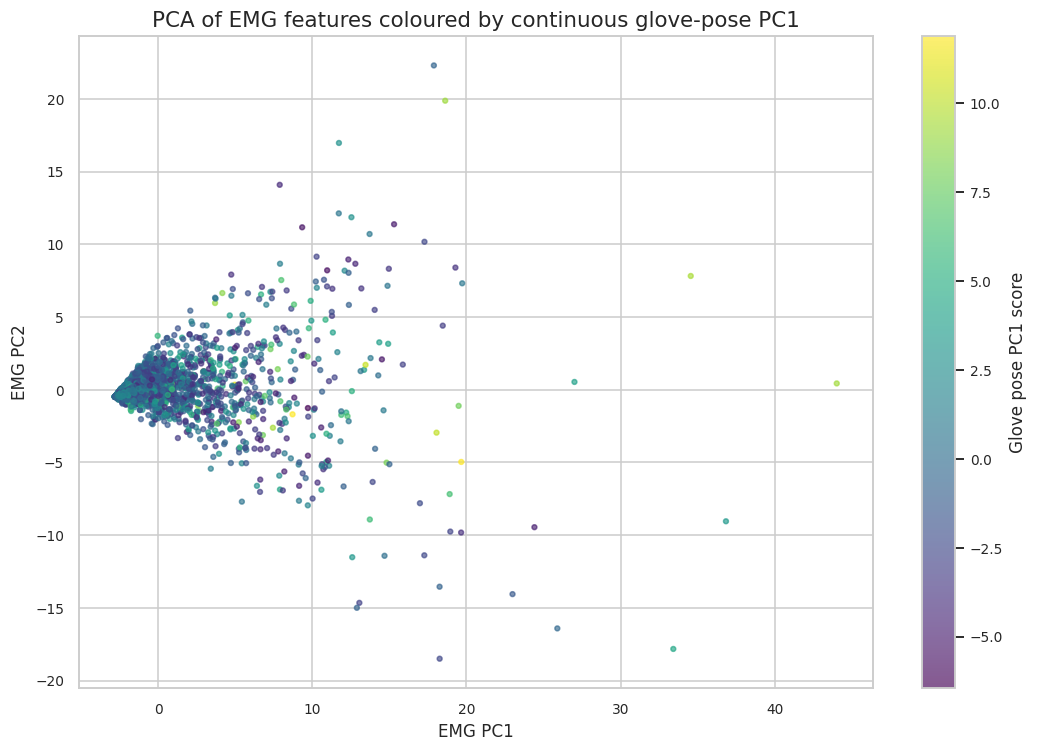

In [21]:
embedding_n = min(EMBEDDING_SAMPLE, len(window_X))
embedding_index = np.sort(rng.choice(len(window_X), embedding_n, replace=False))
X_embedding = window_X.iloc[embedding_index].reset_index(drop=True)
G_embedding = window_G.iloc[embedding_index].reset_index(drop=True)
meta_embedding = window_meta.iloc[embedding_index].reset_index(drop=True)

X_scaled = StandardScaler().fit_transform(X_embedding)
G_scaled = StandardScaler().fit_transform(G_embedding)

glove_pca = PCA(n_components=1, random_state=RANDOM_STATE)
glove_pose_score = glove_pca.fit_transform(G_scaled).ravel()
emg_pca = PCA(n_components=3, random_state=RANDOM_STATE)
P = emg_pca.fit_transform(X_scaled)

print("EMG PCA explained variance PC1–PC3 (%):", (100*emg_pca.explained_variance_ratio_).round(2))
print("Glove pose PC1 explained variance (%):", round(100*glove_pca.explained_variance_ratio_[0], 2))

plt.figure(figsize=(10, 7))
scatter = plt.scatter(P[:, 0], P[:, 1], c=glove_pose_score, s=10, alpha=0.65, cmap="viridis")
plt.title("PCA of EMG features coloured by continuous glove-pose PC1")
plt.xlabel("EMG PC1")
plt.ylabel("EMG PC2")
plt.colorbar(scatter, label="Glove pose PC1 score")
plt.tight_layout()
plt.show()


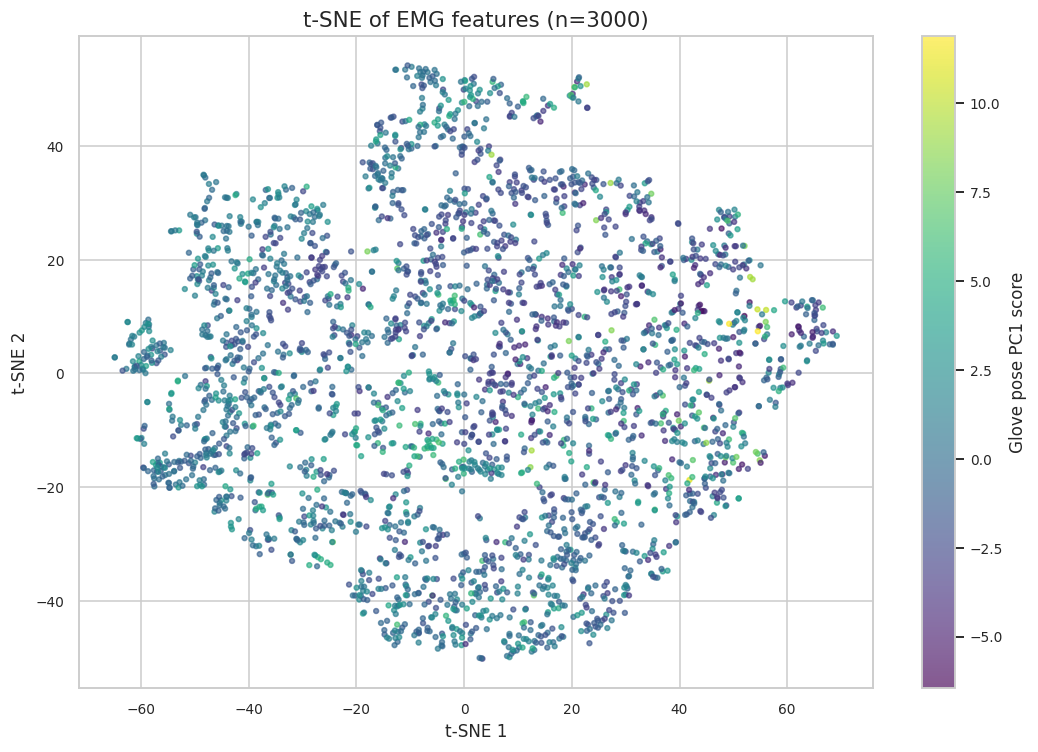

In [22]:
perplexity = min(30, max(5, (embedding_n - 1) // 3))
tsne_result = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity,
    random_state=RANDOM_STATE,
).fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_result[:, 0], tsne_result[:, 1],
    c=glove_pose_score, s=10, alpha=0.65, cmap="viridis"
)
plt.title(f"t-SNE of EMG features (n={embedding_n})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Glove pose PC1 score")
plt.tight_layout()
plt.show()


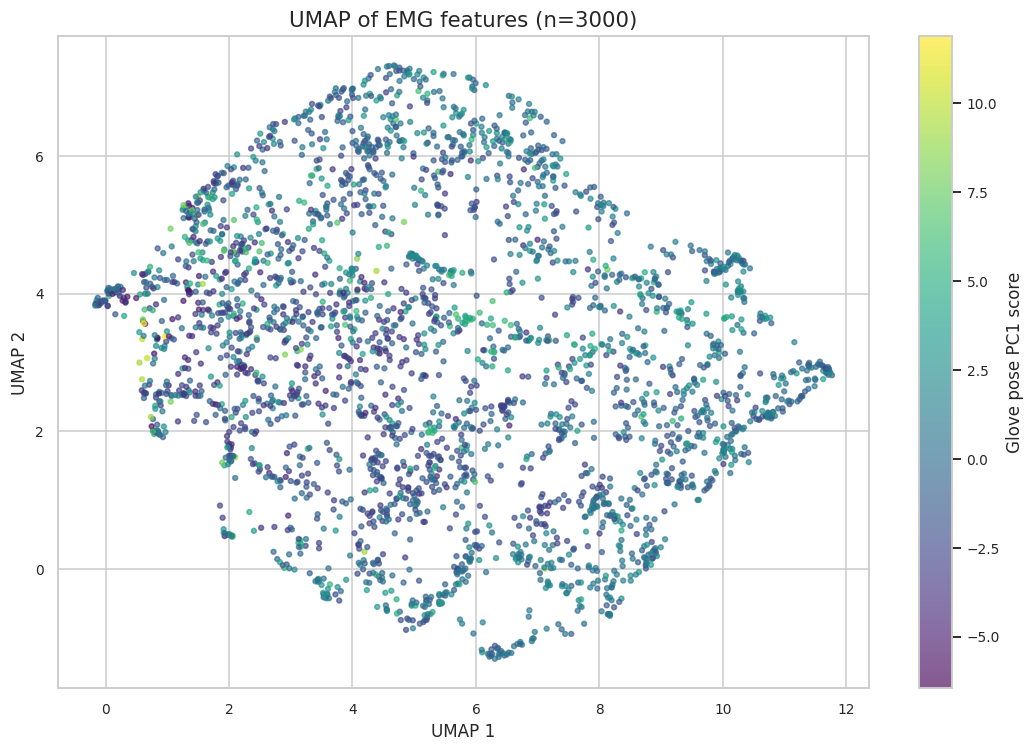

In [23]:
try:
    import umap.umap_ as umap
    umap_result = umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        umap_result[:, 0], umap_result[:, 1],
        c=glove_pose_score, s=10, alpha=0.65, cmap="viridis"
    )
    plt.title(f"UMAP of EMG features (n={embedding_n})")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.colorbar(scatter, label="Glove pose PC1 score")
    plt.tight_layout()
    plt.show()
except Exception as error:
    print("UMAP skipped. Install with `pip install umap-learn`.", type(error).__name__)


In [31]:
try:
    import plotly.express as px
    interactive_df = pd.DataFrame({
        "EMG_PC1": P[:, 0],
        "EMG_PC2": P[:, 1],
        "Glove_pose_PC1": glove_pose_score,
        "Subject": meta_embedding.subject.astype(str),
        "Exercise": meta_embedding.exercise.astype(str),
        "Activity": meta_embedding.activity,
        "Movement": meta_embedding.movement,
    })
    figure = px.scatter(
        interactive_df,
        x="EMG_PC1",
        y="EMG_PC2",
        color="Glove_pose_PC1",
        hover_data=["Subject", "Exercise", "Activity", "Movement"],
        opacity=0.65,
        title="Interactive EMG PCA coloured by continuous glove-pose score",
    )
    figure.update_traces(marker={"size": 6})
    figure.show()
except Exception as error:
    print("Interactive plot skipped. Install Plotly if needed.", type(error).__name__)


# J. Final EDA findings and next target

In [30]:
rest_median = raw_df.loc[raw_df.activity == "Rest", "emg_rms"].median()
movement_median = raw_df.loc[raw_df.activity == "Movement", "emg_rms"].median()
movement_to_rest = movement_median / max(rest_median, 1e-12)

final_findings = pd.DataFrame({
    "Finding": [
        "Dataset coverage", "Synchronization", "Numerical quality",
        "Movement coverage", "Rest–movement EMG difference",
        "Between-subject EMG variability", "Between-subject glove variability",
        "Glove target quality", "Strongest feature–target correlation",
        "Window-level EDA table",
    ],
    "Result": [
        f"{len(inventory_df)} files; {inventory_df.subject.nunique()} subjects; {inventory_df.exercise.nunique()} exercises",
        f"{int(inventory_df.Aligned.sum())}/{len(inventory_df)} files aligned",
        f"Missing={int(inventory_df.Missing_values.sum())}; Infinite={int(inventory_df.Infinite_values.sum())}",
        f"{movement_df.global_label.nunique()}/52 active movements; rest={rest_samples:,} samples",
        f"Movement median EMG RMS is {movement_to_rest:.2f}× rest",
        f"Subject EMG-RMS CV={emg_cv:.1f}%",
        f"Subject glove-range CV={glove_cv:.1f}%",
        "No near-flat targets" if not near_constant_targets else str(near_constant_targets),
        f"max |r|={association_df.abs_r.max():.3f}; mean |r|={association_df.abs_r.mean():.3f}",
        f"{len(window_X):,} windows; 40 EMG features; 22 continuous glove targets",
    ],
})
display(final_findings)


,Finding,Result
0,Dataset coverage,81 files; 27 subjects; 3 exercises
1,Synchronization,81/81 files aligned
2,Numerical quality,Missing=0; Infinite=0
3,Movement coverage,"52/52 active movements; rest=7,290,845 samples"
4,Rest–movement EMG difference,Movement median EMG RMS is 4.57× rest
5,Between-subject EMG variability,Subject EMG-RMS CV=24.9%
6,Between-subject glove variability,Subject glove-range CV=6.2%
7,Glove target quality,No near-flat targets
8,Strongest feature–target correlation,max |r|=0.360; mean |r|=0.088
9,Window-level EDA table,"28,350 windows; 40 EMG features; 22 continuous..."


## EDA conclusion

The dataset is suitable for further modelling when the quality summary confirms all files are aligned and no missing or infinite values are present. EMG activity differs between rest and movement, the synchronized diagrams show temporal association between muscle activation and glove pose, and the correlation analysis identifies useful but non-uniform EMG–glove relationships. Repetition and subject plots also show natural variability, supporting a careful subject-independent evaluation.

**Next target after EDA:** use windowed 10-channel EMG to predict 22 continuous glove values through multi-output regression, and evaluate the final model on subjects excluded completely from training.
